In [107]:
import csv
from pathlib import Path
import numpy as np
from sklearn.model_selection import KFold
import json
import pandas as pd

In [2]:
def get_first_row_csv(csv_file):
    with open(csv_file) as csvfile:
        for index, row in enumerate(csv.reader(csvfile)):
            return row

In [3]:
pathlist = Path('data/templates-with-pid').glob('**/*.csv')
files = {'brups': [], 'ip': []}
for csv_file in pathlist: 
    try:
        fname = get_first_row_csv(csv_file)[0]  
    except TypeError:
        pass
    else:
        if 'BR-UPS'==fname[:6]:
            files['brups'].append(fname)
        else:
            files['ip'].append(fname)

In [4]:
compt_brups, compt_ip = len(files['brups']), len(files['ip'])
print(compt_brups, compt_ip )
print(compt_brups + compt_ip )

2615 6239
8854


In [9]:
patients_brups = np.array(list(set([int(file.split('_')[1]) for file in files['brups']])))
len(patients_brups)

24

In [10]:
patients_ip = np.array(list(set([file.split('_')[1] for file in files['ip']])))
len(patients_ip)

2719

In [26]:
len(patients_ip)+len(patients_brups)

2743

In [12]:
nfold = 5
kfold = KFold(n_splits=nfold, shuffle=True, random_state=1)

In [13]:
def get_5_splits(patients):
    return {fold+1 : {'train': patients[train_ids], 'val':  patients[val_ids]} for fold, (train_ids, val_ids) in enumerate(kfold.split(patients))}

In [16]:
splits_brups = get_5_splits(patients_brups)
splits_ip = get_5_splits(patients_ip)

In [31]:
for fold in splits_brups.keys():
    print(len(splits_brups[fold]['train']), len(splits_brups[fold]['val']),
         len(splits_brups[fold]['train'])+ len(splits_brups[fold]['val']))

19 5 24
19 5 24
19 5 24
19 5 24
20 4 24


In [30]:
for fold in splits_ip.keys():
    print(len(splits_ip[fold]['train']), len(splits_ip[fold]['val']),
         len(splits_ip[fold]['train'])+ len(splits_ip[fold]['val']))

2175 544 2719
2175 544 2719
2175 544 2719
2175 544 2719
2176 543 2719


In [66]:
def convert_lst_to_str(lst):
    return [str(ele) for ele in lst]

In [67]:
splits_global = {str(fold) : {'train': [], 'val':  []} for fold in splits_ip.keys()}
for fold in splits_ip.keys():
    splits_global[str(fold)]['train'].extend(convert_lst_to_str(splits_brups[fold]['train']))
    splits_global[str(fold)]['val'].extend(convert_lst_to_str(splits_brups[fold]['val']))
    splits_global[str(fold)]['train'].extend(convert_lst_to_str(splits_ip[fold]['train']))
    splits_global[str(fold)]['val'].extend(convert_lst_to_str(splits_ip[fold]['val']))

In [68]:
for fold in splits_global.keys():
    print(len(splits_global[fold]['train']), len(splits_global[fold]['val']),
         len(splits_global[fold]['train'])+ len(splits_global[fold]['val']))

2194 549 2743
2194 549 2743
2194 549 2743
2194 549 2743
2196 547 2743


In [69]:
files_patient_brups  = {int(file.split('_')[1]): [] for file in files['brups']}
for file in files['brups']:
    files_patient_brups[int(file.split('_')[1])].append(file) 
nb_recordins_per_patient = [len(item) for key, item in files_patient_brups.items()]
print(max(nb_recordins_per_patient), min(nb_recordins_per_patient))

114 74


In [70]:
files_patient_ip  = {file.split('_')[1]: [] for file in files['ip']}
for file in files['ip']:
    files_patient_ip[file.split('_')[1]].append(file)  
nb_recordins_per_patient = [len(item) for key, item in files_patient_ip.items()]
print(max(nb_recordins_per_patient), min(nb_recordins_per_patient))

12 1


In [71]:
files_patient = {}
for key, item in files_patient_brups.items():
    files_patient[str(key)] = convert_lst_to_str(item)
for key, item in files_patient_ip.items():
    files_patient[str(key)] = convert_lst_to_str(item)
print(len(files_patient))

2743


In [72]:
for fold in splits_global.keys():
    sum_train = sum([len(files_patient[pid]) for pid in splits_global[fold]['train']])
    sum_val = sum([len(files_patient[pid]) for pid in splits_global[fold]['val']])
    total = sum_train + sum_val
    print(f"Number recordings - train: {sum_train} ({round(100*sum_train/total)}%), val: {sum_val}, total: {total}")

Number recordings - train: 7025 (79%), val: 1829, total: 8854
Number recordings - train: 7026 (79%), val: 1828, total: 8854
Number recordings - train: 7077 (80%), val: 1777, total: 8854
Number recordings - train: 7105 (80%), val: 1749, total: 8854
Number recordings - train: 7183 (81%), val: 1671, total: 8854


In [77]:
with open('data/private-database/patient_splits_global.json', 'w') as fp:
    json.dump(splits_global, fp)

In [78]:
with open('data/private-database/files_per_patient.json', 'w') as fp:
    json.dump(files_patient, fp)

In [96]:
def get_qt_ref(csv_file): 
    with open(csv_file) as csvfile:
        for index, row in enumerate(csv.reader(csvfile) ):
            if index==1:
                qon = int(row[0].split(':')[-1]) 
            if index==2:
                toff = int(row[0].split(':')[-1]) 
            if index==3:
                qt = int(row[0].split(':')[-1]) 
        assert(qt==toff-qon)
        return qon, toff, qt

In [112]:
def get_ecgs(csv_file): 
    ecgs = []
    with open(csv_file) as csvfile:
        for index, row in enumerate(csv.reader(csvfile) ):
            if index<5:
                pass
            else:
                ecgs.append(np.array([float(val) for val in row])) 
    df = pd.DataFrame(np.array(ecgs), columns = ['i','ii','iii','avr','avl','avf','v1','v2','v3','v4','v5','v6'])
    return df

In [119]:
labels  = pd.read_csv('data/labels.csv')
labels.head(1)

,id,filename,qpos,tpos
0,id-1,IP-07_01-0001D__20120625164114_1,406,849


In [125]:
pathlist = Path('data/templates-with-pid').glob('**/*.csv') 
for csv_file in pathlist:
    #print(csv_file)
    try:
        fname = get_first_row_csv(csv_file)[0]  
    except TypeError:
        pass
    else: 
        #print(fname)
        assert(fname in list(labels.filename))
        ecgs = get_ecgs(csv_file)
        df.to_csv(f'data/private-database/templates/{fname}.csv', index=False)

In [127]:
from model.data_loader import *

In [162]:
class ECGDatasetStratified(Dataset):
    def __init__(self, shift=False):
        self.directory = 'data/private-database/templates/' 
        self.fname_idx = associate_fname_to_idx(reverse=True)
        self.shift  = shift
        
    def __len__(self):
        'Denotes the total number of samples'
        return len(fname_idx)
    
    def __getitem__(self, index):
        'Generates one sample of data' 
        # Select sample
        fname = self.fname_idx[index]  
        # Load data and get label
        
        templates = pd.read_csv(self.directory+str(fname)+'.csv').transpose().values 
        templates_normalized = [torch.tensor(normalize(template)).float() for template in templates] 
        qt_interval, mask  = get_markers_w_fname(fname)
         
        sample = {'templates': templates_normalized, 
                  'interval': torch.tensor(qt_interval).float(), 
                  'class': torch.tensor(compute_class_qt(qt_interval)).float(), 
                  'mask': torch.tensor(mask).float()}

        if self.shift:
            value_shift = random.randint(-180, 180) 
            transform = Shift(value_shift)  
            sample = transform(sample)
        return sample
    
def associate_fname_to_idx(directory='data/templates-with-pid', reverse=False):
    fname_idx = {}
    index=1
    for csv_file in Path(directory).glob('**/*.csv'):
        try:
            if reverse:
                fname_idx[index] = get_first_row_csv(csv_file)[0]
            else:
                fname_idx[get_first_row_csv(csv_file)[0]] = index
            index+=1
        except:
            pass
    return fname_idx

def get_markers_w_fname(fname, directory='data/', file_labels='labels.csv'):
    '''
    Get Q and T positions
    '''
    mask = [0 for i in range(600)]
    with open(directory+file_labels) as csvfile:
        reader =  csv.reader(csvfile, delimiter=',') 
        for row in reader: 
            if str(fname) in row[1]:
                qonset = int(row[2])
                toffset = int(row[3])
                qt_interval = toffset - qonset
                lower = qonset//2
                upper = toffset//2 + 1
                mask[lower:upper] = [1 for i in range (lower, upper)] 
                return  qt_interval, mask 

In [201]:
data = ECGDatasetStratified()

In [164]:
len(data)

8854

In [181]:
patient_splits = json.load(open("data/private-database/patient_splits_global.json"))
files_per_patient = json.load(open("data/private-database/files_per_patient.json"))
fname_idx_not_reverse = associate_fname_to_idx(reverse=False) 

In [184]:
def flatten(lst):
    new_lst = []
    for ele in lst:
        new_lst.extend(ele)
    return new_lst

In [189]:
for fold, dic in patient_splits.items(): 
    print(fold) 
    train_recs = flatten([files_per_patient[pid] for pid in dic['train']])
    val_recs = flatten([files_per_patient[pid] for pid in dic['val']]) 
    train_ids = [fname_idx_not_reverse[rec] for rec in train_recs]
    val_ids = [fname_idx_not_reverse[rec] for rec in val_recs]
    break

1


In [205]:
import matplotlib.pyplot as plt

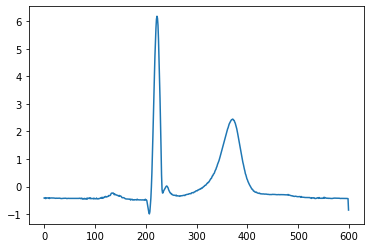

In [208]:
plt.plot(data[val_ids[0]]['templates'][10]);